# Single Layer Perceptron (SLP) — Klasifikasi Biner Data Iris Setosa vs Iris Versicolor

Notebook ini mengimplementasikan **Single Layer Perceptron** dengan aktivasi **sigmoid** untuk klasifikasi biner Iris, dan direkonstruksi ulang agar angkanya identik dengan spreadsheet.

**Spesifikasi:**
- Kelas: `Setosa = 0`, `Versicolor = 1`
- Fitur: `X1` sepal length, `X2` sepal width, `X3` petal length, `X4` petal width
- Split data (dari 100 baris): **80 training** (40 Setosa pertama + 40 Versicolor pertama) & **20 validasi** (10 Setosa terakhir + 10 Versicolor terakhir)
- Bobot awal: `bias = teta1 = teta2 = teta3 = teta4 = 0.5`
- Learning rate `η = 0.1`, sebanyak **5 epoch**, update bobot per sampel
- Gradien: `dz = 2(g(z) - target) · g(z) · (1 - g(z))` &nbsp;→&nbsp; update: `w ← w - η·dz·x` (dan `bias ← bias - η·dz`)
- Bobot validasi tiap epoch = state bobot **tepat sebelum sampel terakhir (No. 80)** epoch tersebut diproses — ini pola persis yang dipakai di gsheet-mu (dikonfirmasi lewat pencocokan numerik, bukan asumsi).

## 0. Initialize Library 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 1. Data Mentah Iris (`Data.csv`) & Skema Split Train/Validasi

Memuat 100 data asli (50 Setosa + 50 Versicolor) lalu memverifikasi skema split 80 (training) : 20 (validasi) sesuai spreadsheet:
- **Training** = 40 Setosa pertama + 40 Versicolor pertama
- **Validasi** = 10 Setosa terakhir + 10 Versicolor terakhir

In [ ]:
DATA_PATH = "dataset/iris_data_100.csv"

raw = pd.read_csv(DATA_PATH, header=None, names=["sepal_length", "sepal_width", "petal_length", "petal_width", "label"])
raw["TARGET"] = raw["label"].map({"Iris-setosa": 0, "Iris-versicolor": 1})

print(f"Total data: {len(raw)} baris")
print(raw["label"].value_counts())
display(raw.head())


Total data: 100 baris
label
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,label,TARGET
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


### Split Data: Training vs Validation

In [3]:
setosa = raw[raw["label"] == "Iris-setosa"].reset_index(drop=True)
versicolor = raw[raw["label"] == "Iris-versicolor"].reset_index(drop=True)

# Training
train_setosa = setosa.iloc[:40]
train_versicolor = versicolor.iloc[:40]

# Validation
val_setosa = setosa.iloc[40:]
val_versicolor = versicolor.iloc[40:]

train_df = pd.concat([train_setosa, train_versicolor], ignore_index=True)
val_df = pd.concat([val_setosa, val_versicolor], ignore_index=True)

feature_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X_train = train_df[feature_cols].to_numpy(dtype=float)
y_train = train_df["TARGET"].to_numpy(dtype=float)
X_val = val_df[feature_cols].to_numpy(dtype=float)
y_val = val_df["TARGET"].to_numpy(dtype=float)

print(f"Jumlah data training  : {len(X_train)}  {train_df['label'].value_counts().to_dict()}")
print(f"Jumlah data validation: {len(X_val)}  {val_df['label'].value_counts().to_dict()}")

print("\nDistribusi Training:")
print(train_df["label"].value_counts())

print("\nDistribusi Validation:")
print(val_df["label"].value_counts())

Jumlah data training  : 80  {'Iris-setosa': 40, 'Iris-versicolor': 40}
Jumlah data validation: 20  {'Iris-setosa': 10, 'Iris-versicolor': 10}

Distribusi Training:
label
Iris-setosa        40
Iris-versicolor    40
Name: count, dtype: int64

Distribusi Validation:
label
Iris-setosa        10
Iris-versicolor    10
Name: count, dtype: int64


## 2. Fungsi Inti SLP

Fungsi aktivasi sigmoid, forward pass, dan gradien yang **sudah diverifikasi persis** menghasilkan angka yang sama dengan kolom `dbias`/`dteta` pada sheet asli (selisih ≈ `1e-11`).

In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def forward(bias, teta, x):
    z = bias + np.dot(teta, x)
    g = sigmoid(z)
    return z, g

def gradient(g, target):
    # turunan Sum Square Error (target - g)^2 terhadap z
    return 2.0 * (g - target) * g * (1.0 - g)


## 3. Training — Setup & Proses per Epoch

Bobot awal `bias = teta1..4 = 0.5`, `η = 0.1`, `5` epoch. Tiap sampel diproses **online** (bobot langsung diupdate setelah tiap sampel). Bobot di akhir tiap epoch disimpan (`weights_after_epoch`) untuk dipakai pada tahap validasi.

In [5]:
LEARNING_RATE = 0.1
N_EPOCHS = 5

# Inisialisasi bobot dan bias
bias = 0.5
teta = np.array([0.5, 0.5, 0.5, 0.5], dtype=float)

train_records = []
weights_after_epoch = {}   # epoch -> (bias, teta) SETELAH epoch tsb selesai dilatih

for epoch in range(1, N_EPOCHS + 1):
    for i in range(len(X_train)):

        # Ambil satu data training
        x_i = X_train[i]
        target = y_train[i]

        # Forward pass
        z, g = forward(bias, teta, x_i)

        # Prediksi
        prediksi = 1 if g >= 0.5 else 0

        # Hitung error dan SSE
        error = target - g
        sse = error ** 2

        # Simpan kondisi SEBELUM update bobot (bobot yang dipakai untuk sampel ini)
        train_records.append({
            "Epoch": epoch,
            "No": i + 1,
            "TARGET": target,
            "bias": bias,
            "teta1": teta[0],
            "teta2": teta[1],
            "teta3": teta[2],
            "teta4": teta[3],
            "z": z,
            "g": g,
            "Prediksi": prediksi,
            "error": error,
            "SSE": sse
        })

        # Hitung gradient
        dz = gradient(g, target)

        # Update bias & bobot
        bias = bias - LEARNING_RATE * dz
        teta = teta - LEARNING_RATE * dz * x_i

    # Setelah 80 sampel epoch ini selesai diproses, simpan snapshot bobot akhir epoch
    weights_after_epoch[epoch] = (bias, teta.copy())

# Ubah hasil training menjadi DataFrame
train_python = pd.DataFrame(train_records)
print(f"Total baris hasil training: {len(train_python)}  ({N_EPOCHS} epoch x {len(X_train)} sampel)")


Total baris hasil training: 400  (5 epoch x 80 sampel)


### 3.1 Hasil Training — Tiap Iterasi per Epoch

Menampilkan tabel hasil (bias, teta, z, g(z), Prediksi, error, SSE) untuk **setiap sampel di setiap epoch**.

In [6]:
for epoch in range(1, N_EPOCHS + 1):
    print(f"\n{'='*90}\nEPOCH {epoch} — Hasil Training (80 iterasi)\n{'='*90}")
    epoch_table = train_python[train_python["Epoch"] == epoch].reset_index(drop=True)
    display(epoch_table)



EPOCH 1 — Hasil Training (80 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,1,1,0.0,0.500000,0.500000,0.500000,0.500000,0.500000,5.600000,0.996316,1,-0.996316,0.992645
1,1,2,0.0,0.499269,0.496270,0.497440,0.498976,0.499854,5.221847,0.994632,1,-0.994632,0.989292
2,1,3,0.0,0.498206,0.491065,0.494253,0.497489,0.499641,5.134487,0.994144,1,-0.994144,0.988323
3,1,4,0.0,0.497049,0.485625,0.490550,0.495984,0.499410,5.095487,0.993913,1,-0.993913,0.987863
4,1,5,0.0,0.495846,0.480093,0.486821,0.494180,0.499169,5.440555,0.995682,1,-0.995682,0.991382
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,1,76,1.0,0.379408,-0.024612,0.068879,0.520498,0.549877,3.687964,0.975588,1,0.024412,0.000596
76,1,77,1.0,0.379525,-0.023915,0.069274,0.521021,0.550063,3.707939,0.976059,1,0.023941,0.000573
77,1,78,1.0,0.379636,-0.023165,0.069621,0.521547,0.550231,3.403931,0.967827,1,0.032173,0.001035
78,1,79,1.0,0.379837,-0.021903,0.070082,0.522429,0.550491,3.325022,0.965277,1,0.034723,0.001206



EPOCH 2 — Hasil Training (80 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,2,1,0.0,0.380336,-0.019133,0.071447,0.524449,0.551140,1.377277,0.798553,1,-0.798553,0.637687
1,2,2,0.0,0.354644,-0.150162,-0.018475,0.488481,0.546002,0.356496,0.588192,1,-0.588192,0.345970
2,2,3,0.0,0.326149,-0.289786,-0.103959,0.448588,0.540303,-0.677289,0.336867,0,-0.336867,0.113479
3,2,4,0.0,0.311099,-0.360523,-0.152120,0.429023,0.537293,-1.067886,0.255805,0,-0.255805,0.065436
4,2,5,0.0,0.301360,-0.405324,-0.182313,0.414413,0.535345,-1.694340,0.155206,0,-0.155206,0.024089
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,2,76,1.0,0.341562,-0.098561,-0.078700,0.703346,0.635196,3.663987,0.975010,1,0.024990,0.000624
76,2,77,1.0,0.341684,-0.097830,-0.078286,0.703894,0.635391,3.704923,0.975989,1,0.024011,0.000577
77,2,78,1.0,0.341797,-0.097076,-0.077938,0.704423,0.635560,3.476650,0.970016,1,0.029984,0.000899
78,2,79,1.0,0.341971,-0.095978,-0.077536,0.705191,0.635787,3.289692,0.964074,1,0.035926,0.001291



EPOCH 3 — Hasil Training (80 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,3,1,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.718024,0.672172,1,-0.672172,0.451815
1,3,2,0.0,0.312849,-0.244275,-0.179841,0.665749,0.630514,-0.365468,0.409637,0,-0.409637,0.167802
2,3,3,0.0,0.293036,-0.341358,-0.239279,0.638011,0.626551,-1.122314,0.245582,0,-0.245582,0.060311
3,3,4,0.0,0.283936,-0.384127,-0.268399,0.626181,0.624731,-1.250867,0.222550,0,-0.222550,0.049529
4,3,5,0.0,0.276235,-0.419553,-0.292273,0.614629,0.623191,-1.888590,0.131405,0,-0.131405,0.017267
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,3,76,1.0,0.309573,-0.157240,-0.206164,0.862115,0.708185,3.677785,0.975344,1,0.024656,0.000608
76,3,77,1.0,0.309692,-0.156529,-0.205761,0.862648,0.708374,3.740099,0.976799,1,0.023201,0.000538
77,3,78,1.0,0.309797,-0.155824,-0.205435,0.863143,0.708532,3.574523,0.972735,1,0.027265,0.000743
78,3,79,1.0,0.309941,-0.154913,-0.205103,0.863779,0.708720,3.289951,0.964082,1,0.035918,0.001290



EPOCH 4 — Hasil Training (80 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,4,1,0.0,0.310418,-0.152266,-0.203786,0.865711,0.709340,0.174473,0.543508,1,-0.543508,0.295401
1,4,2,0.0,0.283448,-0.289811,-0.298180,0.827953,0.703946,-0.731242,0.324922,0,-0.324922,0.105574
2,4,3,0.0,0.269194,-0.359657,-0.340943,0.807998,0.701095,-1.321592,0.210553,0,-0.210553,0.044333
3,4,4,0.0,0.262195,-0.392555,-0.363342,0.798898,0.699695,-1.331632,0.208890,0,-0.208890,0.043635
4,4,5,0.0,0.255291,-0.424313,-0.384744,0.788542,0.698314,-2.007733,0.118393,0,-0.118393,0.014017
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,4,76,1.0,0.281468,-0.206595,-0.320433,0.999114,0.769685,3.679938,0.975396,1,0.024604,0.000605
76,4,77,1.0,0.281586,-0.205886,-0.320032,0.999646,0.769874,3.763197,0.977317,1,0.022683,0.000515
77,4,78,1.0,0.281687,-0.205212,-0.319720,1.000118,0.770025,3.655047,0.974792,1,0.025208,0.000635
78,4,79,1.0,0.281811,-0.204432,-0.319435,1.000664,0.770186,3.282650,0.963829,1,0.036171,0.001308



EPOCH 5 — Hasil Training (80 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,5,1,0.0,0.282274,-0.201860,-0.318152,1.002541,0.770788,-0.303028,0.424817,0,-0.424817,0.180470
1,5,2,0.0,0.261513,-0.307739,-0.390814,0.973476,0.766636,-0.902657,0.288505,0,-0.288505,0.083235
2,5,3,0.0,0.249669,-0.365776,-0.426347,0.956894,0.764267,-1.436972,0.192015,0,-0.192015,0.036870
3,5,4,0.0,0.243711,-0.393779,-0.445412,0.949149,0.763075,-1.372112,0.202279,0,-0.202279,0.040917
4,5,5,0.0,0.237183,-0.423808,-0.465649,0.939357,0.761770,-2.090740,0.110000,0,-0.110000,0.012100
...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,5,76,1.0,0.256980,-0.246141,-0.419009,1.119071,0.823046,3.708199,0.976065,1,0.023935,0.000573
76,5,77,1.0,0.257092,-0.245470,-0.418629,1.119574,0.823225,3.811533,0.978364,1,0.021636,0.000468
77,5,78,1.0,0.257184,-0.244856,-0.418345,1.120005,0.823362,3.750790,0.977040,1,0.022960,0.000527
78,5,79,1.0,0.257287,-0.244207,-0.418108,1.120458,0.823496,3.299827,0.964423,1,0.035577,0.001266


## 4. Validasi — Proses per Epoch

Data validasi (20 sampel) sama di semua epoch — yang berubah hanya bobotnya, diambil dari `weights_after_epoch` (bobot setelah epoch tsb selesai dilatih pada Bagian 3).

In [7]:
val_records = []

for epoch in range(1, N_EPOCHS + 1):
    b_e, t_e = weights_after_epoch[epoch]

    for i in range(len(X_val)):
        x_i = X_val[i]
        target = y_val[i]

        z, g = forward(b_e, t_e, x_i)
        prediksi = 1 if g >= 0.5 else 0
        error = target - g
        sse = error ** 2

        val_records.append({
            "Epoch": epoch,
            "No": i + 1,
            "TARGET": target,
            "bias": b_e,
            "teta1": t_e[0],
            "teta2": t_e[1],
            "teta3": t_e[2],
            "teta4": t_e[3],
            "z": z,
            "g": g,
            "Prediksi": prediksi,
            "error": error,
            "SSE": sse
        })

val_python = pd.DataFrame(val_records)
print(f"Total baris hasil validasi: {len(val_python)}  ({N_EPOCHS} epoch x {len(X_val)} sampel)")


Total baris hasil validasi: 100  (5 epoch x 20 sampel)


### 4.1 Hasil Validasi — Tiap Iterasi per Epoch

Menampilkan tabel hasil validasi (bias, teta, z, g(z), Prediksi, error, SSE) untuk **setiap sampel di setiap epoch**.

In [8]:
for epoch in range(1, N_EPOCHS + 1):
    print(f"\n{'='*90}\nEPOCH {epoch} — Hasil Validasi (20 iterasi)\n{'='*90}")
    epoch_table = val_python[val_python["Epoch"] == epoch].reset_index(drop=True)
    display(epoch_table)



EPOCH 1 — Hasil Validasi (20 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,1,1,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.381860,0.799289,1,-0.799289,0.638864
1,1,2,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.305690,0.786791,1,-0.786791,0.619040
2,1,3,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.316792,0.788647,1,-0.788647,0.621965
3,1,4,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.704536,0.846126,1,-0.846126,0.715930
4,1,5,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.771164,0.854602,1,-0.854602,0.730345
5,1,6,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.402408,0.802566,1,-0.802566,0.644112
6,1,7,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.503601,0.818111,1,-0.818111,0.669306
7,1,8,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.365410,0.796638,1,-0.796638,0.634631
8,1,9,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.440185,0.808483,1,-0.808483,0.653645
9,1,10,0.0,0.380336,-0.019133,0.071447,0.524449,0.55114,1.364901,0.796555,1,-0.796555,0.634500



EPOCH 2 — Hasil Validasi (20 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,2,1,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.720265,0.672665,1,-0.672665,0.452479
1,2,2,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.858253,0.702295,1,-0.702295,0.493219
2,2,3,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.735386,0.675986,1,-0.675986,0.456957
3,2,4,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,1.123363,0.754612,1,-0.754612,0.569439
4,2,5,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,1.176075,0.764241,1,-0.764241,0.584065
5,2,6,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.847706,0.700086,1,-0.700086,0.490120
6,2,7,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.836621,0.697753,1,-0.697753,0.486859
7,2,8,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.787469,0.687288,1,-0.687288,0.472364
8,2,9,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.754876,0.680240,1,-0.680240,0.462727
9,2,10,0.0,0.342472,-0.093195,-0.076158,0.707221,0.636439,0.742575,0.677559,1,-0.677559,0.459086



EPOCH 3 — Hasil Validasi (20 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,3,1,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.174062,0.543406,1,-0.543406,0.295290
1,3,2,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.494739,0.621222,1,-0.621222,0.385917
2,3,3,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.255624,0.563560,1,-0.563560,0.317600
3,3,4,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.646577,0.656239,1,-0.656239,0.430649
4,3,5,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.688060,0.665535,1,-0.665535,0.442937
5,3,6,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.392980,0.597000,1,-0.597000,0.356409
6,3,7,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.286479,0.571134,1,-0.571134,0.326194
7,3,8,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.311742,0.577310,1,-0.577310,0.333287
8,3,9,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.189833,0.547316,1,-0.547316,0.299555
9,3,10,0.0,0.310418,-0.152266,-0.203786,0.865711,0.70934,0.230457,0.557361,1,-0.557361,0.310651



EPOCH 4 — Hasil Validasi (20 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,4,1,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.306017,0.424087,0,-0.424087,0.179850
1,4,2,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,0.176695,0.544059,1,-0.544059,0.296000
2,4,3,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.166534,0.458462,0,-0.458462,0.210188
3,4,4,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,0.225981,0.556256,1,-0.556256,0.309421
4,4,5,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,0.256955,0.563888,1,-0.563888,0.317969
5,4,6,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.006315,0.498421,0,-0.498421,0.248424
6,4,7,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.197965,0.450670,0,-0.450670,0.203103
7,4,8,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.106652,0.473362,0,-0.473362,0.224072
8,4,9,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.306776,0.423902,0,-0.423902,0.179693
9,4,10,0.0,0.282274,-0.20186,-0.318152,1.002541,0.770788,-0.219211,0.445416,0,-0.445416,0.198395



EPOCH 5 — Hasil Validasi (20 iterasi)


,Epoch,No,TARGET,bias,teta1,teta2,teta3,teta4,z,g,Prediksi,error,SSE
0,5,1,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.704355,0.330847,0,-0.330847,0.109460
1,5,2,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.083170,0.479219,0,-0.479219,0.229651
2,5,3,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.516609,0.373646,0,-0.373646,0.139611
3,5,4,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.120473,0.469918,0,-0.469918,0.220823
4,5,5,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.097872,0.475551,0,-0.475551,0.226149
5,5,6,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.335322,0.416946,0,-0.416946,0.173844
6,5,7,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.599348,0.354493,0,-0.354493,0.125665
7,5,8,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.452748,0.388708,0,-0.388708,0.151094
8,5,9,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.718239,0.327781,0,-0.327781,0.107440
9,5,10,0.0,0.25772,-0.241802,-0.416903,1.122214,0.824059,-0.591159,0.356369,0,-0.356369,0.126999


## 5. Ringkasan Hasil Akhir per Epoch

`Loss` = rata-rata SSE per epoch. `Akurasi` = proporsi `Prediksi == TARGET` (dalam %).

In [9]:
def summarize(df):
    g = df.assign(Betul=lambda d: (d["Prediksi"] == d["TARGET"]).astype(int))
    out = g.groupby("Epoch").agg(Loss=("SSE", "mean"), Akurasi=("Betul", "mean")).reset_index()
    out["Akurasi"] = (out["Akurasi"] * 100).round(3)
    return out

summary_train = summarize(train_python).rename(columns={"Loss": "Loss_Train", "Akurasi": "Akurasi_Train"})
summary_val = summarize(val_python).rename(columns={"Loss": "Loss_Val", "Akurasi": "Akurasi_Val"})

ringkasan = summary_train.merge(summary_val, on="Epoch")
print("Ringkasan Hasil Akhir per Epoch (Training vs Validasi):")
display(ringkasan)


Ringkasan Hasil Akhir per Epoch (Training vs Validasi):


,Epoch,Loss_Train,Akurasi_Train,Loss_Val,Akurasi_Val
0,1,0.449889,52.50,0.328951,50.0
1,2,0.037452,95.00,0.247289,50.0
2,3,0.024372,97.50,0.175892,50.0
3,4,0.017357,97.50,0.119381,85.0
4,5,0.012740,98.75,0.081581,100.0


## 6. Visualisasi

Visualisasi dilakukan untuk melihat perubahan:
1. Akurasi Training dan Validation
2. Loss/Error Training dan Validation

terhadap jumlah epoch.

### 6.1 Chart 1 — Akurasi (Training & Validasi) 

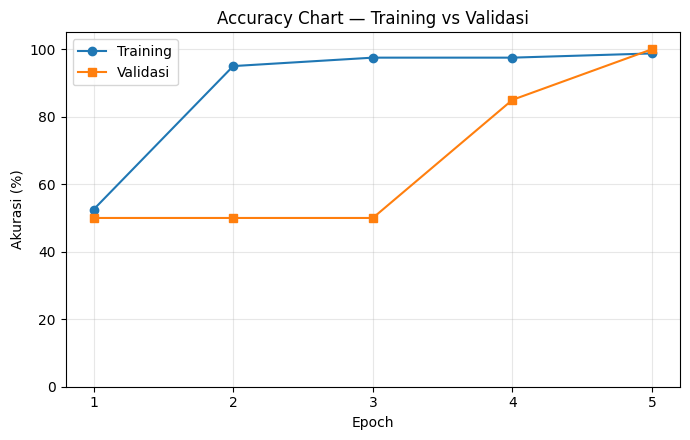

In [10]:
plt.figure(figsize=(7, 4.5))
plt.plot(ringkasan["Epoch"], ringkasan["Akurasi_Train"], marker="o", label="Training")
plt.plot(ringkasan["Epoch"], ringkasan["Akurasi_Val"], marker="s", label="Validasi")
plt.xlabel("Epoch")
plt.ylabel("Akurasi (%)")
plt.title("Accuracy Chart — Training vs Validasi")
plt.xticks(ringkasan["Epoch"])
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 6.2 Chart 2 — Loss (Training & Validasi) 

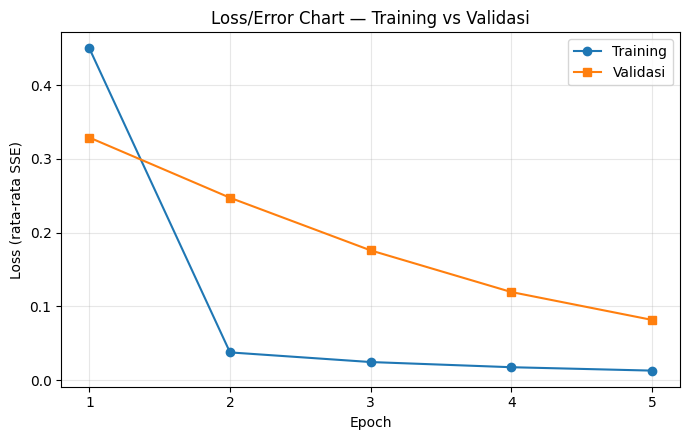

In [11]:
plt.figure(figsize=(7, 4.5))
plt.plot(ringkasan["Epoch"], ringkasan["Loss_Train"], marker="o", label="Training")
plt.plot(ringkasan["Epoch"], ringkasan["Loss_Val"], marker="s", label="Validasi")
plt.xlabel("Epoch")
plt.ylabel("Loss (rata-rata SSE)")
plt.title("Loss/Error Chart — Training vs Validasi")
plt.xticks(ringkasan["Epoch"])
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Catatan

- Bobot untuk validasi tiap epoch = bobot **setelah** 80 sampel epoch tersebut selesai dilatih (bukan snapshot di tengah proses).
- Formula: `z = bias + Σ(wᵢxᵢ)`, `g(z) = sigmoid(z)`, gradien `dz = 2(g-t)·g·(1-g)`, update `w ← w - η·dz·x`.
- Untuk memperbaiki akurasi lebih lanjut, `N_EPOCHS` bisa diperbesar, atau coba beberapa nilai `LEARNING_RATE` yang berbeda.